In [1]:
!pip install pytorch-lightning
import pytorch_lightning as pl
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchmetrics import Accuracy
import numpy as np
import glob
import os

Defaulting to user installation because normal site-packages is not writeable


In [2]:
class RFDataset(Dataset):
    '''Custom dataset for RF signal numpy files'''
    
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        # Load npy file
        data = np.load(self.file_paths[idx]).astype(np.float32)
        
        # Normalize
        data = (data - data.mean()) / (data.std() + 1e-8)
        
        # Add channel dimension (1, 512, 243)
        data = np.expand_dims(data, axis=0)
        
        # Convert to tensor
        data = torch.from_numpy(data)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        
        if self.transform:
            data = self.transform(data)
        
        return data, label

In [3]:
class RFDataModule(pl.LightningDataModule):
    def __init__(self, data_dir, train_labels_file, test_labels_file, batch_size=32, val_split=0.15):
        super().__init__()
        self.data_dir = data_dir
        self.train_labels_file = train_labels_file
        self.test_labels_file = test_labels_file
        self.batch_size = batch_size
        self.val_split = val_split  # 15% of train data for validation
        self.dims = (1, 512, 243)
        self.num_classes = 9
    
    def prepare_data(self):
        files = glob.glob(os.path.join(self.data_dir, "*.npy"))
        print(f"Found {len(files)} .npy files in {self.data_dir}")
    
    def setup(self, stage=None):
        if stage == 'fit' or stage is None:
            # Load full train set
            train_files, train_labels = self._load_split(self.train_labels_file)
            full_train_dataset = RFDataset(train_files, train_labels)
            
            # Split into train and validation
            total_train = len(full_train_dataset)
            val_size = int(self.val_split * total_train)
            train_size = total_train - val_size
            
            self.rf_train, self.rf_val = random_split(
                full_train_dataset, 
                [train_size, val_size],
                generator=torch.Generator().manual_seed(42)  # For reproducibility
            )
            
            print(f"Train set: {train_size} samples")
            print(f"Val set: {val_size} samples")
        
        if stage == 'test' or stage is None:
            # Load test set
            test_files, test_labels = self._load_split(self.test_labels_file)
            self.rf_test = RFDataset(test_files, test_labels)
            print(f"Test set: {len(test_files)} samples")
    
    def _load_split(self, labels_file):
        """Load file paths and labels from a label file"""
        file_paths = []
        labels = []
        
        with open(labels_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 2:
                    file_path = parts[0]  # e.g., "data/004809.npy"
                    label = int(parts[1])
                    
                    # Extract filename and create full path
                    filename = os.path.basename(file_path)
                    full_path = os.path.join(self.data_dir, filename)
                    
                    if os.path.exists(full_path):
                        file_paths.append(full_path)
                        labels.append(label)
                    else:
                        print(f"Warning: File not found: {full_path}")
        
        print(f"Loaded {len(file_paths)} samples from {labels_file}")
        return file_paths, labels
        
    def train_dataloader(self):
        return DataLoader(self.rf_train, batch_size=self.batch_size, shuffle=True, num_workers=8)
    
    def val_dataloader(self):
        return DataLoader(self.rf_val, batch_size=self.batch_size, num_workers=8)
    
    def test_dataloader(self):
        return DataLoader(self.rf_test, batch_size=self.batch_size, num_workers=8)

In [4]:
class RFLitModel(pl.LightningModule):
    '''model architecture, training, testing and validation loops'''
    
    def __init__(self, input_shape, num_classes, learning_rate=1e-3):
        super().__init__()
        
        # log hyperparameters
        self.save_hyperparameters()
        self.learning_rate = learning_rate
        
        # model architecture - adapted for 512x243 input
        self.conv1 = nn.Conv2d(1, 32, 3, 1, padding=1)  # 1 channel input
        self.conv2 = nn.Conv2d(32, 32, 3, 1, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, 1, padding=1)
        self.conv4 = nn.Conv2d(64, 64, 3, 1, padding=1)
        
        self.pool1 = torch.nn.MaxPool2d(2)
        self.pool2 = torch.nn.MaxPool2d(2)
        
        # Batch norm for stability
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        
        n_sizes = self._get_output_shape(input_shape)
        
        # linear layers for classifier head
        self.fc1 = nn.Linear(n_sizes, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)
        
        self.dropout = nn.Dropout(0.5)
        self.accuracy = Accuracy(task="multiclass", num_classes=num_classes)
    
    def _get_output_shape(self, shape):
        '''returns the size of the output tensor from the conv layers'''
        batch_size = 1
        input = torch.autograd.Variable(torch.rand(batch_size, *shape))
        output_feat = self._feature_extractor(input)
        n_size = output_feat.data.view(batch_size, -1).size(1)
        return n_size
    
    def _feature_extractor(self, x):
        '''extract features from the conv blocks'''
        x = F.relu(self.conv1(x))
        x = self.pool1(F.relu(self.conv2(x)))
        x = self.bn1(x)
        
        x = F.relu(self.conv3(x))
        x = self.pool2(F.relu(self.conv4(x)))
        x = self.bn2(x)
        return x
    
    def forward(self, x):
        '''produce final model output'''
        x = self._feature_extractor(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x
    
    # train loop
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        
        # metric
        preds = torch.argmax(logits, dim=1)
        acc = self.accuracy(preds, y)
        self.log('train_loss', loss, on_step=True, on_epoch=True, logger=True)
        self.log('train_acc', acc, on_step=True, on_epoch=True, logger=True)
        return loss
    
    # validation loop
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        
        preds = torch.argmax(logits, dim=1)
        acc = self.accuracy(preds, y)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)
        return loss
    
    # test loop
    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        
        preds = torch.argmax(logits, dim=1)
        acc = self.accuracy(preds, y)
        self.log('test_loss', loss, prog_bar=True)
        self.log('test_acc', acc, prog_bar=True)
        return loss
    
    # optimizers
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

In [5]:
if __name__ == "__main__":
    # instantiate classes with the labels file
    dm = RFDataModule(data_dir='subset_dataset/data/', train_labels_file='subset_dataset/train.txt', test_labels_file='subset_dataset/test.txt', batch_size=32,val_split=0.15)
    dm.prepare_data()
    dm.setup()
    
    model = RFLitModel((1, 512, 243), dm.num_classes)
    
    checkpoint_callback = pl.callbacks.ModelCheckpoint(monitor='val_acc', mode='max', save_top_k=1)
    
    trainer = pl.Trainer(max_epochs=20, accelerator='auto', devices=1, callbacks=[checkpoint_callback])
    
    trainer.fit(model, dm)
    trainer.test(dataloaders=dm.test_dataloader())

Found 625 .npy files in subset_dataset/data/
Loaded 500 samples from subset_dataset/train.txt
Train set: 425 samples
Val set: 75 samples
Loaded 125 samples from subset_dataset/test.txt
Test set: 125 samples


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/x-ein/.local/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default

   | Name     | Type               | Params | Mode 
---------------------------------------------------------
0  | conv1    | Conv2d             | 320    | train
1  | conv2    | Conv2d             | 9.2 K  | train
2  | conv3    | Conv2d             | 18.5 K | train
3  | conv4    | Conv2d             | 36.9 K | train
4  | pool1    | MaxPool2d          | 0

Found 625 .npy files in subset_dataset/data/
Loaded 500 samples from subset_dataset/train.txt
Train set: 425 samples
Val set: 75 samples


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/x-ein/.local/lib/python3.12/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (14) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


...

`Trainer.fit` stopped: `max_epochs=20` reached.
/home/x-ein/.local/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/checkpoint_connector.py:149: `.test(ckpt_path=None)` was called without a model. The best model of the previous `fit` call will be used. You can pass `.test(ckpt_path='best')` to use the best model or `.test(ckpt_path='last')` to use the last model. If you pass a value, this warning will be silenced.
Restoring states from the checkpoint path at /home/x-ein/lightning_logs/version_1/checkpoints/epoch=2-step=42.ckpt


Found 625 .npy files in subset_dataset/data/
Loaded 125 samples from subset_dataset/test.txt
Test set: 125 samples


Loaded model weights from the checkpoint at /home/x-ein/lightning_logs/version_1/checkpoints/epoch=2-step=42.ckpt
SLURM auto-requeueing enabled. Setting signal handlers.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.6240000128746033
        test_loss           1.3018766641616821
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


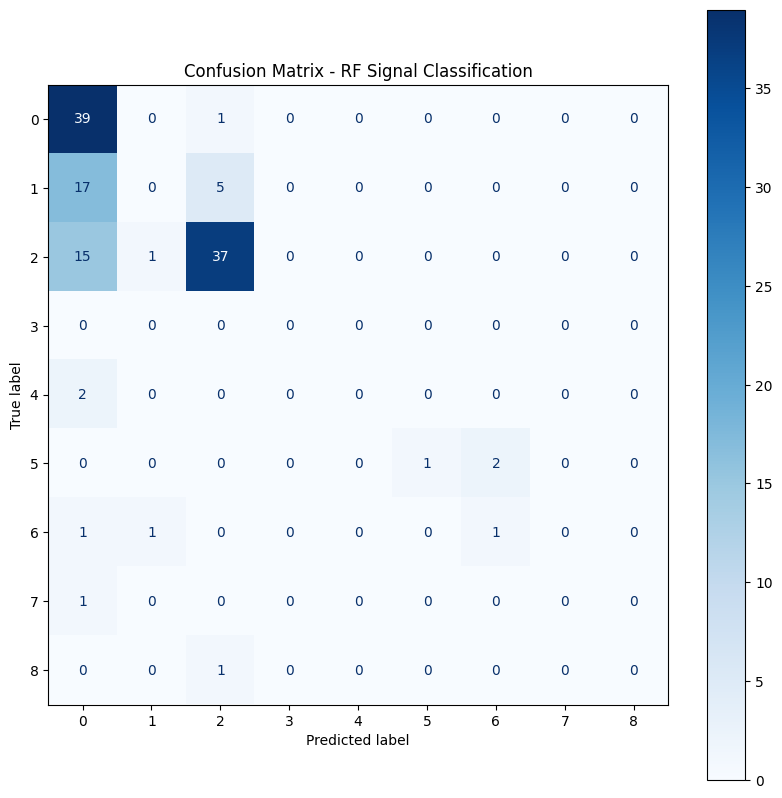

Confusion matrix saved!


In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get predictions on test set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in dm.test_dataloader():
        x, y = batch
        logits = model(x)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Create confusion matrix - specify all labels from 0 to 8
cm = confusion_matrix(all_labels, all_preds, labels=list(range(9)))  # Add labels parameter

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=range(9))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix - RF Signal Classification')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrix saved!")